# Benchmark do `givp` — Funções Clássicas com Solução Conhecida

Notebook de validação do **GRASP-ILS-VND-PR**, agora consumido como **biblioteca externa** (`givp`) instalada via Poetry. Aplicado a problemas clássicos de otimização global cujo ótimo é conhecido analiticamente ou via algoritmo exato.

Para cada problema medimos:

- **Erro absoluto** $|f_{\text{obtido}} - f^*|$
- **Erro relativo** (%) ao ótimo conhecido
- **Robustez**: média e desvio padrão entre $N$ rodadas independentes
- **Tempo de execução**

A biblioteca é importada via `from givp import givp, GIVPConfig` — sem nenhum acoplamento ao código interno do projeto SOG2.


## 1. Setup e Importações

In [ ]:
from __future__ import annotations

import copy
import time
import warnings
from collections.abc import Callable, Sequence
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from givp import GIVPConfig, givp
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)

print("givp importado como biblioteca externa.")
print(f"Seed: {SEED}")

givp importado como biblioteca externa.
Seed: 42


## 2. Wrapper Genérico para o `givp`

Função utilitária que executa $N$ rodadas independentes do otimizador, captura o histórico de convergência via `iteration_callback` e devolve a melhor solução, valor objetivo, tempos e históricos.


In [ ]:
@dataclass
class RunResult:
    """Saída de uma única execução do solver."""

    x: np.ndarray
    fun: float
    nfev: int
    elapsed_s: float
    history: list[float] = field(default_factory=list)


@dataclass
class SolveResult:
    """Saída agregada de N rodadas independentes."""

    runs: list[RunResult]
    best_run_idx: int

    @property
    def best(self) -> RunResult:
        return self.runs[self.best_run_idx]

    @property
    def values(self) -> np.ndarray:
        return np.asarray([r.fun for r in self.runs], dtype=float)

    @property
    def times(self) -> np.ndarray:
        return np.asarray([r.elapsed_s for r in self.runs], dtype=float)


def _default_config() -> GIVPConfig:
    """Configuração razoável para problemas de pequeno-médio porte."""
    return GIVPConfig(
        max_iterations=60,
        alpha=0.15,
        vnd_iterations=30,
        ils_iterations=8,
        perturbation_strength=4,
        num_candidates_per_step=15,
        elite_size=5,
        path_relink_frequency=10,
        early_stop_threshold=40,
        adaptive_alpha=True,
        n_workers=1,
    )


def solve_with_grasp(
    objective_fn: Callable[[np.ndarray], float],
    lower: Sequence[float],
    upper: Sequence[float],
    *,
    config: GIVPConfig | None = None,
    n_runs: int = 5,
    direction: str = "minimize",
    integer_split: int | None = None,
    verbose: bool = False,
) -> SolveResult:
    """Executa N rodadas do `givp` e devolve resultados agregados.

    Args:
        objective_fn: função objetivo escalar.
        lower: limites inferiores das variáveis.
        upper: limites superiores das variáveis.
        config: configuração do GRASP (default = `_default_config`).
        n_runs: número de rodadas independentes.
        direction: 'minimize' ou 'maximize'.
        integer_split: índice a partir do qual variáveis são inteiras.
        verbose: imprime progresso da biblioteca.

    Returns:
        SolveResult com a lista de RunResult e índice da melhor rodada.
    """
    cfg_base = config or _default_config()
    if integer_split is not None:
        cfg_base = copy.copy(cfg_base)
        cfg_base.integer_split = integer_split

    bounds = list(zip(lower, upper, strict=True))
    runs: list[RunResult] = []

    for _ in range(n_runs):
        history: list[float] = []

        def _cb(
            _it: int, cost: float, _x: np.ndarray, _h: list[float] = history
        ) -> None:
            _h.append(float(cost))

        t0 = time.perf_counter()
        res = givp(
            objective_fn,
            bounds,
            direction=direction,
            config=cfg_base,
            iteration_callback=_cb,
            verbose=verbose,
        )
        elapsed = time.perf_counter() - t0
        runs.append(
            RunResult(
                x=np.asarray(res.x, dtype=float),
                fun=float(res.fun),
                nfev=int(res.nfev),
                elapsed_s=elapsed,
                history=history,
            )
        )

    values = np.asarray([r.fun for r in runs])
    best_idx = int(np.argmax(values) if direction == "maximize" else np.argmin(values))
    return SolveResult(runs=runs, best_run_idx=best_idx)

## 3. Função de Avaliação e Comparação

Recebe um problema, executa o GRASP e devolve um dicionário com métricas comparáveis ao ótimo conhecido.

In [ ]:
def evaluate_problem(
    name: str,
    fn: Callable[[np.ndarray], float],
    lower: Sequence[float],
    upper: Sequence[float],
    optimum_value: float,
    *,
    optimum_x: Sequence[float] | np.ndarray | None = None,
    n_runs: int = 5,
    config: GIVPConfig | None = None,
    direction: str = "minimize",
    integer_split: int | None = None,
    rel_tol: float = 1.0,
) -> dict:
    """Resolve um problema com GRASP e compara com o ótimo conhecido.

    `rel_tol` é apenas usado como denominador suave: erro relativo é definido
    como ``|f - f*| / max(|f*|, rel_tol)`` para evitar divisão por zero quando
    ``f* == 0``.
    """
    sr = solve_with_grasp(
        fn,
        lower,
        upper,
        config=config,
        n_runs=n_runs,
        direction=direction,
        integer_split=integer_split,
    )
    best = sr.best
    values = sr.values
    err_abs = float(np.abs(best.fun - optimum_value))
    denom = max(abs(optimum_value), rel_tol)
    err_rel_pct = 100.0 * err_abs / denom

    x_dist: float | None = None
    if optimum_x is not None:
        x_dist = float(np.linalg.norm(best.x - np.asarray(optimum_x, dtype=float)))

    return {
        "problem": name,
        "dim": len(list(lower)),
        "optimum": float(optimum_value),
        "best_fun": float(best.fun),
        "mean_fun": float(np.mean(values)),
        "std_fun": float(np.std(values)),
        "err_abs": err_abs,
        "err_rel_pct": err_rel_pct,
        "x_distance_to_optimum": x_dist,
        "mean_time_s": float(np.mean(sr.times)),
        "n_runs": n_runs,
        "best_x": best.x,
        "_solve_result": sr,
    }


def print_problem_result(res: dict) -> None:
    """Imprime resumo de um problema individual."""
    print(f'── {res["problem"]} (dim={res["dim"]}) ──')
    print(f'   ótimo conhecido     : {res["optimum"]:.6e}')
    print(f'   melhor obtido       : {res["best_fun"]:.6e}')
    print(f'   média ± dp          : {res["mean_fun"]:.6e} ± {res["std_fun"]:.3e}')
    print(f'   erro absoluto       : {res["err_abs"]:.3e}')
    print(f'   erro relativo (%)   : {res["err_rel_pct"]:.4f}%')
    if res["x_distance_to_optimum"] is not None:
        print(f'   ||x - x*||          : {res["x_distance_to_optimum"]:.4f}')
    print(f'   tempo médio (s)     : {res["mean_time_s"]:.2f}')


# Container para acumular resultados
ALL_RESULTS: list[dict] = []
DEFAULT_RUNS = 3

## 4. Problema 1: Sphere Function

$$f(x) = \sum_{i=1}^{n} x_i^2, \quad x \in [-5.12, 5.12]^n, \quad x^* = 0,\; f^* = 0.$$

Função convexa e separável — teste de sanidade básico.

In [4]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x * x))


N_SPHERE = 10
res_sphere = evaluate_problem(
    "Sphere",
    sphere,
    lower=[-5.12] * N_SPHERE,
    upper=[5.12] * N_SPHERE,
    optimum_value=0.0,
    optimum_x=[0.0] * N_SPHERE,
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_sphere)
print_problem_result(res_sphere)

── Sphere (dim=10) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 7.946460e-03
   média ± dp          : 8.313549e-03 ± 2.965e-04
   erro absoluto       : 7.946e-03
   erro relativo (%)   : 0.7946%
   ||x - x*||          : 0.0891
   tempo médio (s)     : 1.85


## 5. Problema 2: Rosenbrock Function

$$f(x) = \sum_{i=1}^{n-1} \left[ 100\,(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right], \quad x \in [-2.048, 2.048]^n, \quad x^* = (1,\dots,1),\; f^* = 0.$$

Vale curvo de banana — convexo apenas localmente; teste clássico de algoritmos de busca local.

In [5]:
def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))


N_ROSEN = 5
res_rosen = evaluate_problem(
    "Rosenbrock",
    rosenbrock,
    lower=[-2.048] * N_ROSEN,
    upper=[2.048] * N_ROSEN,
    optimum_value=0.0,
    optimum_x=[1.0] * N_ROSEN,
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_rosen)
print_problem_result(res_rosen)

── Rosenbrock (dim=5) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 5.906239e-02
   média ± dp          : 1.630426e-01 ± 8.504e-02
   erro absoluto       : 5.906e-02
   erro relativo (%)   : 5.9062%
   ||x - x*||          : 0.2282
   tempo médio (s)     : 3.96


## 6. Problema 3: Rastrigin Function (multimodal)

$$f(x) = 10 n + \sum_{i=1}^{n} \left[ x_i^2 - 10 \cos(2\pi x_i) \right], \quad x \in [-5.12, 5.12]^n,\quad x^* = 0,\; f^* = 0.$$

Altamente multimodal — testa capacidade de escapar de muitos ótimos locais.

In [6]:
def rastrigin(x: np.ndarray) -> float:
    n = x.size
    return float(10.0 * n + np.sum(x * x - 10.0 * np.cos(2.0 * np.pi * x)))


N_RAST = 10
res_rast = evaluate_problem(
    "Rastrigin",
    rastrigin,
    lower=[-5.12] * N_RAST,
    upper=[5.12] * N_RAST,
    optimum_value=0.0,
    optimum_x=[0.0] * N_RAST,
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_rast)
print_problem_result(res_rast)

── Rastrigin (dim=10) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 1.096019e+00
   média ± dp          : 1.751285e+00 ± 4.635e-01
   erro absoluto       : 1.096e+00
   erro relativo (%)   : 109.6019%
   ||x - x*||          : 0.9816
   tempo médio (s)     : 4.35


## 7. Problema 4: Ackley Function

$$f(x) = -20 \exp\!\left(-0.2 \sqrt{\tfrac{1}{n}\sum x_i^2}\right) - \exp\!\left(\tfrac{1}{n}\sum \cos(2\pi x_i)\right) + 20 + e,$$

com $x \in [-32.768, 32.768]^n$, $x^* = 0$, $f^* = 0$.

In [7]:
def ackley(x: np.ndarray) -> float:
    n = x.size
    s1 = np.sum(x * x) / n
    s2 = np.sum(np.cos(2.0 * np.pi * x)) / n
    return float(-20.0 * np.exp(-0.2 * np.sqrt(s1)) - np.exp(s2) + 20.0 + np.e)


N_ACK = 10
res_ack = evaluate_problem(
    "Ackley",
    ackley,
    lower=[-32.768] * N_ACK,
    upper=[32.768] * N_ACK,
    optimum_value=0.0,
    optimum_x=[0.0] * N_ACK,
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_ack)
print_problem_result(res_ack)

── Ackley (dim=10) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 8.863161e-01
   média ± dp          : 1.451212e+00 ± 4.119e-01
   erro absoluto       : 8.863e-01
   erro relativo (%)   : 88.6316%
   ||x - x*||          : 0.3271
   tempo médio (s)     : 2.32


## 8. Problema 5: Griewank Function

$$f(x) = 1 + \frac{1}{4000}\sum_{i=1}^n x_i^2 - \prod_{i=1}^n \cos\!\left(\frac{x_i}{\sqrt{i}}\right),$$

com $x \in [-600, 600]^n$, $x^* = 0$, $f^* = 0$.

In [8]:
def griewank(x: np.ndarray) -> float:
    idx = np.arange(1, x.size + 1)
    s = np.sum(x * x) / 4000.0
    p = float(np.prod(np.cos(x / np.sqrt(idx))))
    return float(1.0 + s - p)


N_GRI = 10
res_gri = evaluate_problem(
    "Griewank",
    griewank,
    lower=[-600.0] * N_GRI,
    upper=[600.0] * N_GRI,
    optimum_value=0.0,
    optimum_x=[0.0] * N_GRI,
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_gri)
print_problem_result(res_gri)

── Griewank (dim=10) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 7.773898e-01
   média ± dp          : 8.128957e-01 ± 3.017e-02
   erro absoluto       : 7.774e-01
   erro relativo (%)   : 77.7390%
   ||x - x*||          : 25.2820
   tempo médio (s)     : 2.02


## 9. Problema 6: Schwefel Function

$$f(x) = 418.9829\,n - \sum_{i=1}^n x_i \sin\!\left(\sqrt{|x_i|}\right),$$

com $x \in [-500, 500]^n$, $x_i^* \approx 420.9687$, $f^* \approx 0$. Ótimo global afastado do centro — teste clássico de exploração.

In [9]:
def schwefel(x: np.ndarray) -> float:
    n = x.size
    return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))


N_SCH = 10
res_sch = evaluate_problem(
    "Schwefel",
    schwefel,
    lower=[-500.0] * N_SCH,
    upper=[500.0] * N_SCH,
    optimum_value=0.0,
    optimum_x=[420.9687] * N_SCH,
    n_runs=DEFAULT_RUNS,
    rel_tol=418.9829 * N_SCH,  # normaliza pelo valor máximo teórico
)
ALL_RESULTS.append(res_sch)
print_problem_result(res_sch)

── Schwefel (dim=10) ──
   ótimo conhecido     : 0.000000e+00
   melhor obtido       : 1.818700e+02
   média ± dp          : 2.434152e+02 ± 8.445e+01
   erro absoluto       : 1.819e+02
   erro relativo (%)   : 4.3408%
   ||x - x*||          : 722.8030
   tempo médio (s)     : 2.94


## 10. Problema 7: Knapsack Binário (DP como solução exata)

Mochila 0/1 com 20 itens: maximizar valor total respeitando capacidade $C$. O GRASP recebe variáveis contínuas em $[0,1]$, que são arredondadas para $\{0,1\}$ antes de avaliar. Excesso de capacidade é penalizado por um termo grande.

O ótimo é calculado por **programação dinâmica** (tempo $O(n C)$).

In [10]:
def knapsack_dp(
    values: np.ndarray, weights: np.ndarray, capacity: int
) -> tuple[int, np.ndarray]:
    """Mochila 0/1 via programação dinâmica. Retorna (valor_otimo, vetor_binario)."""
    n = values.size
    dp = np.zeros((n + 1, capacity + 1), dtype=np.int64)
    for i in range(1, n + 1):
        w_i = int(weights[i - 1])
        v_i = int(values[i - 1])
        for c in range(capacity + 1):
            dp[i, c] = dp[i - 1, c]
            if w_i <= c and dp[i - 1, c - w_i] + v_i > dp[i, c]:
                dp[i, c] = dp[i - 1, c - w_i] + v_i
    # Recuperação da solução
    sol = np.zeros(n, dtype=np.int64)
    c = capacity
    for i in range(n, 0, -1):
        if dp[i, c] != dp[i - 1, c]:
            sol[i - 1] = 1
            c -= int(weights[i - 1])
    return int(dp[n, capacity]), sol


rng = np.random.default_rng(SEED)
N_KNAP = 20
ks_values = rng.integers(10, 100, size=N_KNAP)
ks_weights = rng.integers(5, 50, size=N_KNAP)
KS_CAPACITY = int(ks_weights.sum() // 2)

ks_optimum_value, ks_optimum_x = knapsack_dp(ks_values, ks_weights, KS_CAPACITY)
print(f"Capacidade: {KS_CAPACITY}")
print(
    f"Ótimo (DP): valor={ks_optimum_value}, itens selecionados={int(ks_optimum_x.sum())}"
)


def knapsack_penalty(x: np.ndarray) -> float:
    """Minimiza o negativo do valor + penalidade por excesso de peso."""
    selection = (x > 0.5).astype(np.int64)
    total_value = float(np.sum(selection * ks_values))
    total_weight = float(np.sum(selection * ks_weights))
    overflow = max(0.0, total_weight - KS_CAPACITY)
    return -total_value + 1000.0 * overflow


res_knap = evaluate_problem(
    "Knapsack 0/1 (n=20)",
    knapsack_penalty,
    lower=[0.0] * N_KNAP,
    upper=[1.0] * N_KNAP,
    optimum_value=float(-ks_optimum_value),  # objetivo é minimização de -valor
    optimum_x=ks_optimum_x.astype(float),
    n_runs=DEFAULT_RUNS,
    rel_tol=float(ks_optimum_value),
)
ALL_RESULTS.append(res_knap)
print_problem_result(res_knap)
print(f'   valor GRASP (selecionado): {-res_knap["best_fun"]:.0f}')
print(f"   valor ótimo DP            : {ks_optimum_value}")

Capacidade: 281
Ótimo (DP): valor=871, itens selecionados=12
── Knapsack 0/1 (n=20) (dim=20) ──
   ótimo conhecido     : -8.710000e+02
   melhor obtido       : -8.590000e+02
   média ± dp          : -8.533333e+02 ± 5.437e+00
   erro absoluto       : 1.200e+01
   erro relativo (%)   : 1.3777%
   ||x - x*||          : 2.0619
   tempo médio (s)     : 4.76
   valor GRASP (selecionado): 859
   valor ótimo DP            : 871


## 11. Problema 8: Bin Packing 1D (lower bound trivial)

Empacotar $n$ itens de pesos $w_i$ em caixas de capacidade $C$ minimizando o número de caixas usadas. Lower bound trivial: $L = \lceil \sum w_i / C \rceil$.

Codificação: variáveis contínuas $x_i \in [0, K)$, com o bin de cada item dado por $\lfloor x_i \rfloor$. Violações de capacidade e bins vazios intermediários são penalizados.

In [11]:
BP_CAPACITY = 10
bp_weights = np.array([6, 5, 5, 4, 4, 3, 3, 2, 2, 2, 6, 5, 3, 4, 2], dtype=float)
BP_N = bp_weights.size
BP_MAX_BINS = BP_N  # pior caso: 1 item por bin

bp_lower_bound = int(np.ceil(bp_weights.sum() / BP_CAPACITY))
print(
    f"Itens: {BP_N}, capacidade: {BP_CAPACITY}, soma dos pesos: {bp_weights.sum():.0f}"
)
print(f"Lower bound trivial: {bp_lower_bound} bins")


def bin_packing_cost(x: np.ndarray) -> float:
    """Minimiza (bins usados) + penalidade por estouro de capacidade."""
    assignments = np.clip(np.floor(x).astype(np.int64), 0, BP_MAX_BINS - 1)
    loads = np.bincount(assignments, weights=bp_weights, minlength=BP_MAX_BINS)
    used = int(np.sum(loads > 0))
    overflow = float(np.sum(np.maximum(loads - BP_CAPACITY, 0.0)))
    return float(used) + 50.0 * overflow


res_bp = evaluate_problem(
    "Bin Packing 1D",
    bin_packing_cost,
    lower=[0.0] * BP_N,
    upper=[float(BP_MAX_BINS - 1e-6)] * BP_N,
    optimum_value=float(bp_lower_bound),
    n_runs=DEFAULT_RUNS,
    rel_tol=float(bp_lower_bound),
)
ALL_RESULTS.append(res_bp)
print_problem_result(res_bp)
assign_best = np.clip(np.floor(res_bp["best_x"]).astype(int), 0, BP_MAX_BINS - 1)
used_best = int(np.sum(np.bincount(assign_best, minlength=BP_MAX_BINS) > 0))
print(f"   bins usados pelo GRASP: {used_best} (lower bound: {bp_lower_bound})")

Itens: 15, capacidade: 10, soma dos pesos: 56
Lower bound trivial: 6 bins
── Bin Packing 1D (dim=15) ──
   ótimo conhecido     : 6.000000e+00
   melhor obtido       : 6.000000e+00
   média ± dp          : 6.333333e+00 ± 4.714e-01
   erro absoluto       : 0.000e+00
   erro relativo (%)   : 0.0000%
   tempo médio (s)     : 5.45
   bins usados pelo GRASP: 6 (lower bound: 6)


## 12. Problema 9: Quadratic Assignment Problem (Nug5)

Instância clássica `Nug5` da QAPLIB ($n=5$, ótimo = **50**). Custo:

$$f(\pi) = \sum_{i,j} F_{ij}\, D_{\pi(i)\,\pi(j)}.$$

**Codificação random-keys**: variáveis contínuas em $[0, 1]$ — a permutação é $\pi = \text{argsort}(x)$.

In [12]:
# Instância Nug5 da QAPLIB (ótimo conhecido = 50)
QAP_FLOW = np.array(
    [
        [0, 5, 2, 4, 1],
        [5, 0, 3, 0, 2],
        [2, 3, 0, 0, 0],
        [4, 0, 0, 0, 5],
        [1, 2, 0, 5, 0],
    ],
    dtype=float,
)
QAP_DIST = np.array(
    [
        [0, 1, 1, 2, 3],
        [1, 0, 2, 1, 2],
        [1, 2, 0, 1, 2],
        [2, 1, 1, 0, 1],
        [3, 2, 2, 1, 0],
    ],
    dtype=float,
)
QAP_OPTIMUM = 50
QAP_N = QAP_FLOW.shape[0]


def qap_cost(x: np.ndarray) -> float:
    """Random-keys: permutação = argsort(x)."""
    pi = np.argsort(x)
    return float(np.sum(QAP_FLOW * QAP_DIST[np.ix_(pi, pi)]))


res_qap = evaluate_problem(
    "QAP Nug5",
    qap_cost,
    lower=[0.0] * QAP_N,
    upper=[1.0] * QAP_N,
    optimum_value=float(QAP_OPTIMUM),
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_qap)
print_problem_result(res_qap)
pi_best = np.argsort(res_qap["best_x"]).tolist()
print(f"   permutação GRASP: {pi_best}")

── QAP Nug5 (dim=5) ──
   ótimo conhecido     : 5.000000e+01
   melhor obtido       : 5.000000e+01
   média ± dp          : 5.000000e+01 ± 0.000e+00
   erro absoluto       : 0.000e+00
   erro relativo (%)   : 0.0000%
   tempo médio (s)     : 2.61
   permutação GRASP: [1, 3, 4, 0, 2]


## 13. Problema 10: G06 (restrito não-linear)

$$\min\; f(x) = (x_1 - 10)^3 + (x_2 - 20)^3$$

sujeito a

$$g_1: (x_1-5)^2 + (x_2-5)^2 \geq 100, \qquad g_2: (x_1-6)^2 + (x_2-5)^2 \leq 82.81,$$

com $13 \leq x_1 \leq 100$, $0 \leq x_2 \leq 100$, $f^* \approx -6961.8139$ em $x^* \approx (14.095, 0.843)$.

Restrições tratadas por **penalização externa quadrática**.

In [13]:
G06_OPTIMUM = -6961.81387558015
G06_PENALTY = 1e6


def g06(x: np.ndarray) -> float:
    x1, x2 = float(x[0]), float(x[1])
    obj = (x1 - 10.0) ** 3 + (x2 - 20.0) ** 3
    # g1: -(x1-5)^2 - (x2-5)^2 + 100 <= 0  -> violação quando > 0
    v1 = max(0.0, -((x1 - 5.0) ** 2) - (x2 - 5.0) ** 2 + 100.0)
    # g2: (x1-6)^2 + (x2-5)^2 - 82.81 <= 0 -> violação quando > 0
    v2 = max(0.0, (x1 - 6.0) ** 2 + (x2 - 5.0) ** 2 - 82.81)
    return obj + G06_PENALTY * (v1 * v1 + v2 * v2)


res_g06 = evaluate_problem(
    "G06 (restrito)",
    g06,
    lower=[13.0, 0.0],
    upper=[100.0, 100.0],
    optimum_value=G06_OPTIMUM,
    optimum_x=[14.095, 0.843],
    n_runs=DEFAULT_RUNS,
)
ALL_RESULTS.append(res_g06)
print_problem_result(res_g06)
print(f'   x obtido: {res_g06["best_x"].round(4).tolist()}')

── G06 (restrito) (dim=2) ──
   ótimo conhecido     : -6.961814e+03
   melhor obtido       : -6.859003e+03
   média ± dp          : -6.758439e+03 ± 7.450e+01
   erro absoluto       : 1.028e+02
   erro relativo (%)   : 1.4768%
   ||x - x*||          : 0.1023
   tempo médio (s)     : 4.39
   x obtido: [14.1405, 0.9347]


## 14. Tabela Consolidada de Resultados

In [14]:
df_consolidado = pd.DataFrame(
    [
        {
            "Problema": r["problem"],
            "Dim": r["dim"],
            "Ótimo": r["optimum"],
            "Melhor obtido": r["best_fun"],
            "Média": r["mean_fun"],
            "DP": r["std_fun"],
            "Erro abs": r["err_abs"],
            "Erro rel (%)": r["err_rel_pct"],
            "Tempo médio (s)": r["mean_time_s"],
            "||x - x*||": r["x_distance_to_optimum"],
        }
        for r in ALL_RESULTS
    ]
)
df_consolidado_sorted = df_consolidado.sort_values("Erro rel (%)").reset_index(
    drop=True
)
df_consolidado_sorted.round(
    {
        "Ótimo": 4,
        "Melhor obtido": 4,
        "Média": 4,
        "DP": 4,
        "Erro abs": 4,
        "Erro rel (%)": 4,
        "Tempo médio (s)": 2,
        "||x - x*||": 4,
    }
)

,Problema,Dim,Ótimo,Melhor obtido,Média,DP,Erro abs,Erro rel (%),Tempo médio (s),||x - x*||
0,Bin Packing 1D,15,6.0000,6.0000,6.3333,0.4714,0.0000,0.0000,5.45,NaN
1,QAP Nug5,5,50.0000,50.0000,50.0000,0.0000,0.0000,0.0000,2.61,NaN
2,Sphere,10,0.0000,0.0079,0.0083,0.0003,0.0079,0.7946,1.85,0.0891
3,Knapsack 0/1 (n=20),20,-871.0000,-859.0000,-853.3333,5.4365,12.0000,1.3777,4.76,2.0619
4,G06 (restrito),2,-6961.8139,-6859.0028,-6758.4386,74.5030,102.8110,1.4768,4.39,0.1023
5,Schwefel,10,0.0000,181.8700,243.4152,84.4496,181.8700,4.3408,2.94,722.8030
6,Rosenbrock,5,0.0000,0.0591,0.1630,0.0850,0.0591,5.9062,3.96,0.2282
7,Griewank,10,0.0000,0.7774,0.8129,0.0302,0.7774,77.7390,2.02,25.2820
8,Ackley,10,0.0000,0.8863,1.4512,0.4119,0.8863,88.6316,2.32,0.3271
9,Rastrigin,10,0.0000,1.0960,1.7513,0.4635,1.0960,109.6019,4.35,0.9816


## 15. Visualização Comparativa: Erro Relativo ao Ótimo

Verde: erro < 1% (excelente). Amarelo: 1–10% (aceitável). Vermelho: > 10% (precisa ajuste).

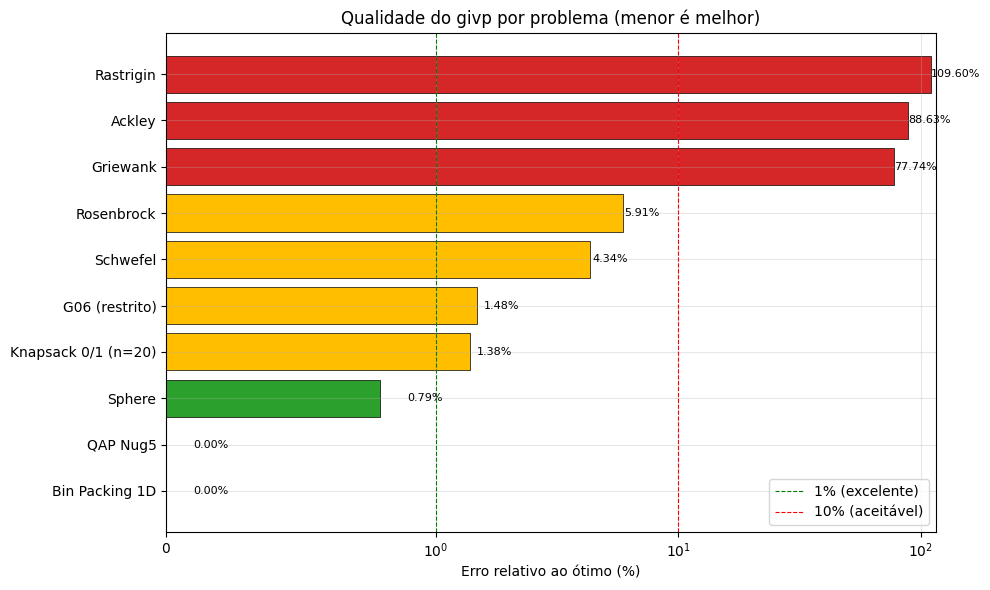

In [15]:
df_plot = df_consolidado_sorted.copy()
colors_err = []
for e in df_plot["Erro rel (%)"]:
    if e < 1.0:
        colors_err.append("#2ca02c")  # verde
    elif e < 10.0:
        colors_err.append("#ffbf00")  # amarelo
    else:
        colors_err.append("#d62728")  # vermelho

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    df_plot["Problema"],
    df_plot["Erro rel (%)"],
    color=colors_err,
    edgecolor="black",
    linewidth=0.5,
)
ax.set_xlabel("Erro relativo ao ótimo (%)")
ax.set_title("Qualidade do givp por problema (menor é melhor)")
ax.axvline(1.0, color="green", linestyle="--", linewidth=0.8, label="1% (excelente)")
ax.axvline(10.0, color="red", linestyle="--", linewidth=0.8, label="10% (aceitável)")
for i, (e, _v) in enumerate(
    zip(df_plot["Erro rel (%)"], df_plot["Melhor obtido"], strict=False)
):
    ax.text(e + 0.1, i, f"{e:.2f}%", va="center", fontsize=8)
ax.legend(loc="lower right")
ax.set_xscale("symlog", linthresh=1.0)
plt.tight_layout()
plt.show()

## 16. Curvas de Convergência por Problema

Melhor custo acumulado a cada iteração, por rodada independente.

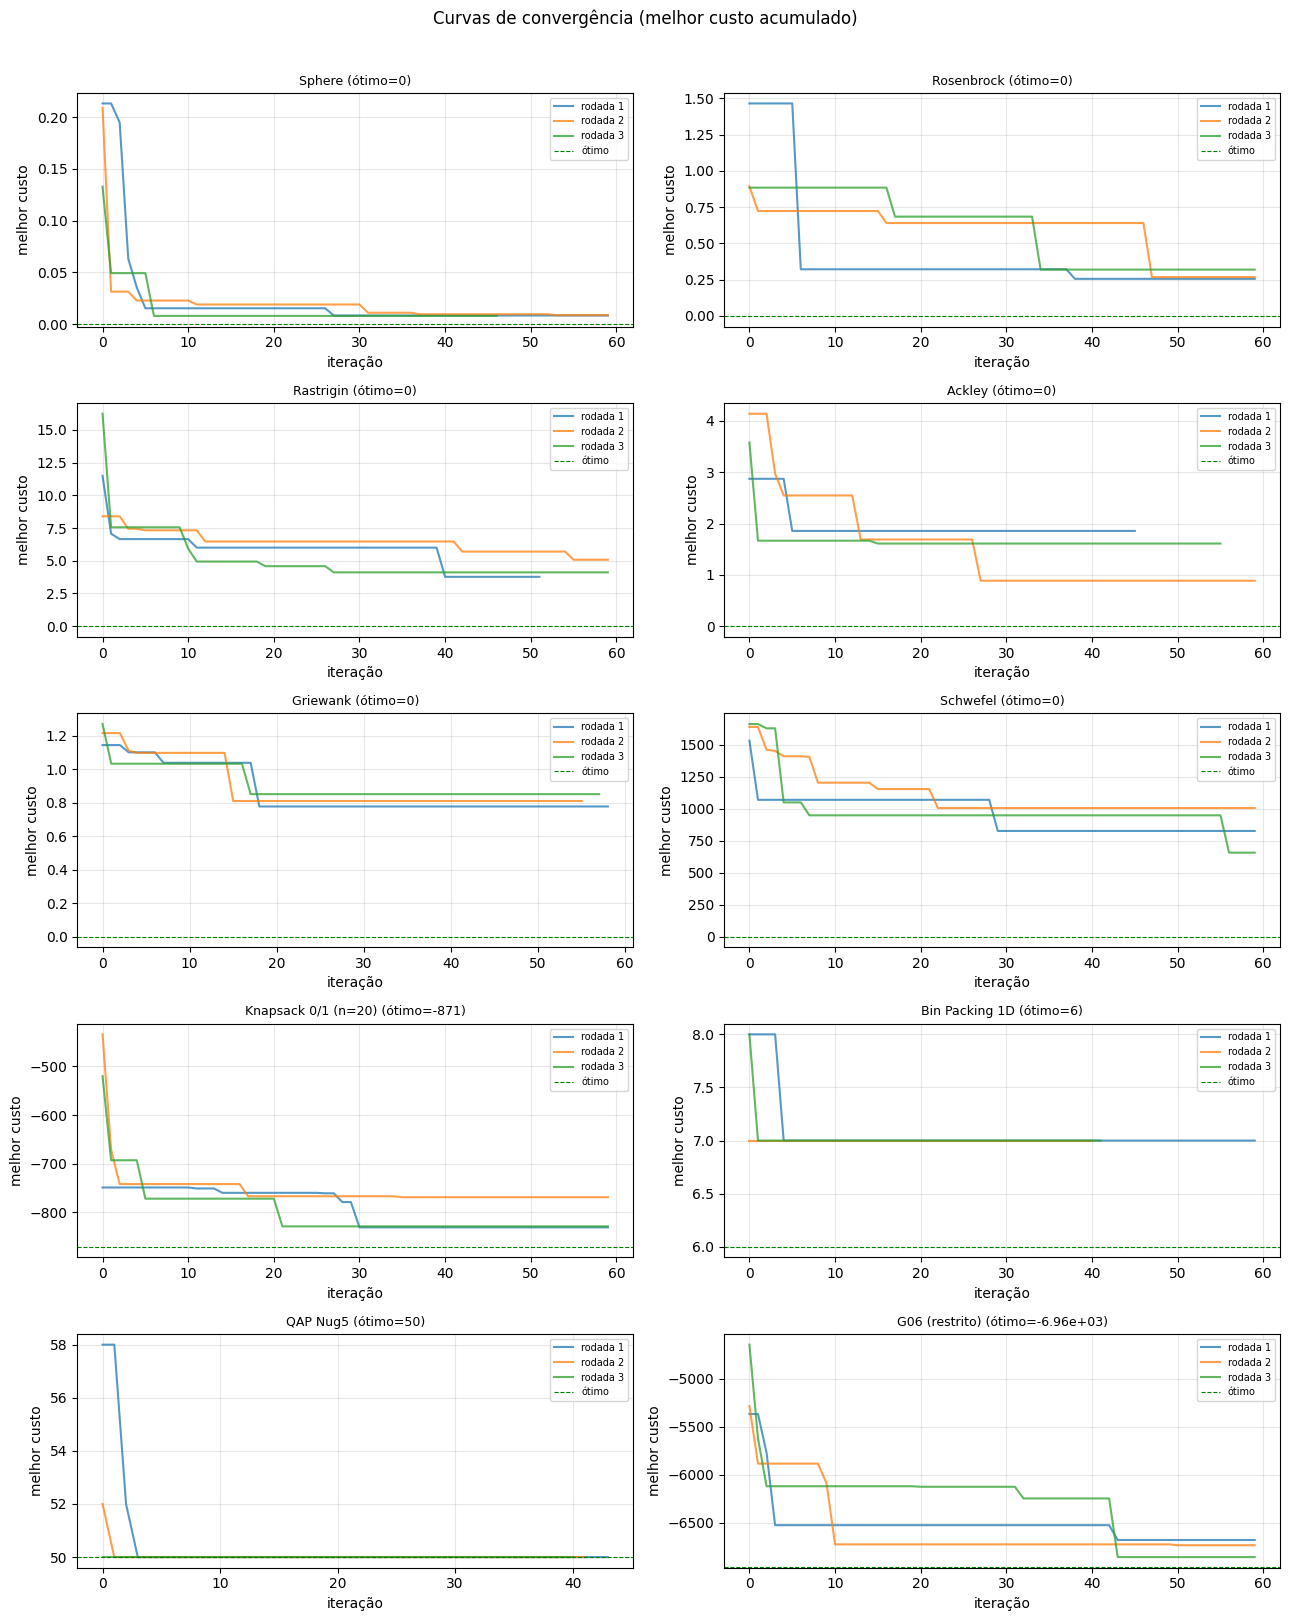

In [16]:
n_problems = len(ALL_RESULTS)
cols = 2
rows = int(np.ceil(n_problems / cols))
fig, axes = plt.subplots(rows, cols, figsize=(13, 3.2 * rows))
axes_flat = np.atleast_1d(axes).flatten()

for ax, res in zip(axes_flat, ALL_RESULTS, strict=False):
    sr: SolveResult = res["_solve_result"]
    for k, run in enumerate(sr.runs):
        if not run.history:
            continue
        best_acum = np.minimum.accumulate(run.history)
        ax.plot(best_acum, label=f"rodada {k + 1}", alpha=0.75)
    ax.axhline(
        res["optimum"], color="green", linestyle="--", linewidth=0.8, label="ótimo"
    )
    ax.set_title(f'{res["problem"]} (ótimo={res["optimum"]:.3g})', fontsize=9)
    ax.set_xlabel("iteração")
    ax.set_ylabel("melhor custo")
    ax.legend(fontsize=7, loc="upper right")

for ax in axes_flat[n_problems:]:
    ax.axis("off")

plt.suptitle("Curvas de convergência (melhor custo acumulado)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 17. Análise de Robustez (Múltiplas Rodadas)

Boxplot do valor objetivo final em $N$ rodadas, com linha horizontal no ótimo. Coeficiente de variação $\mathrm{CV} = \sigma / |\mu|$ mede estabilidade do algoritmo (quanto menor, mais reprodutível).

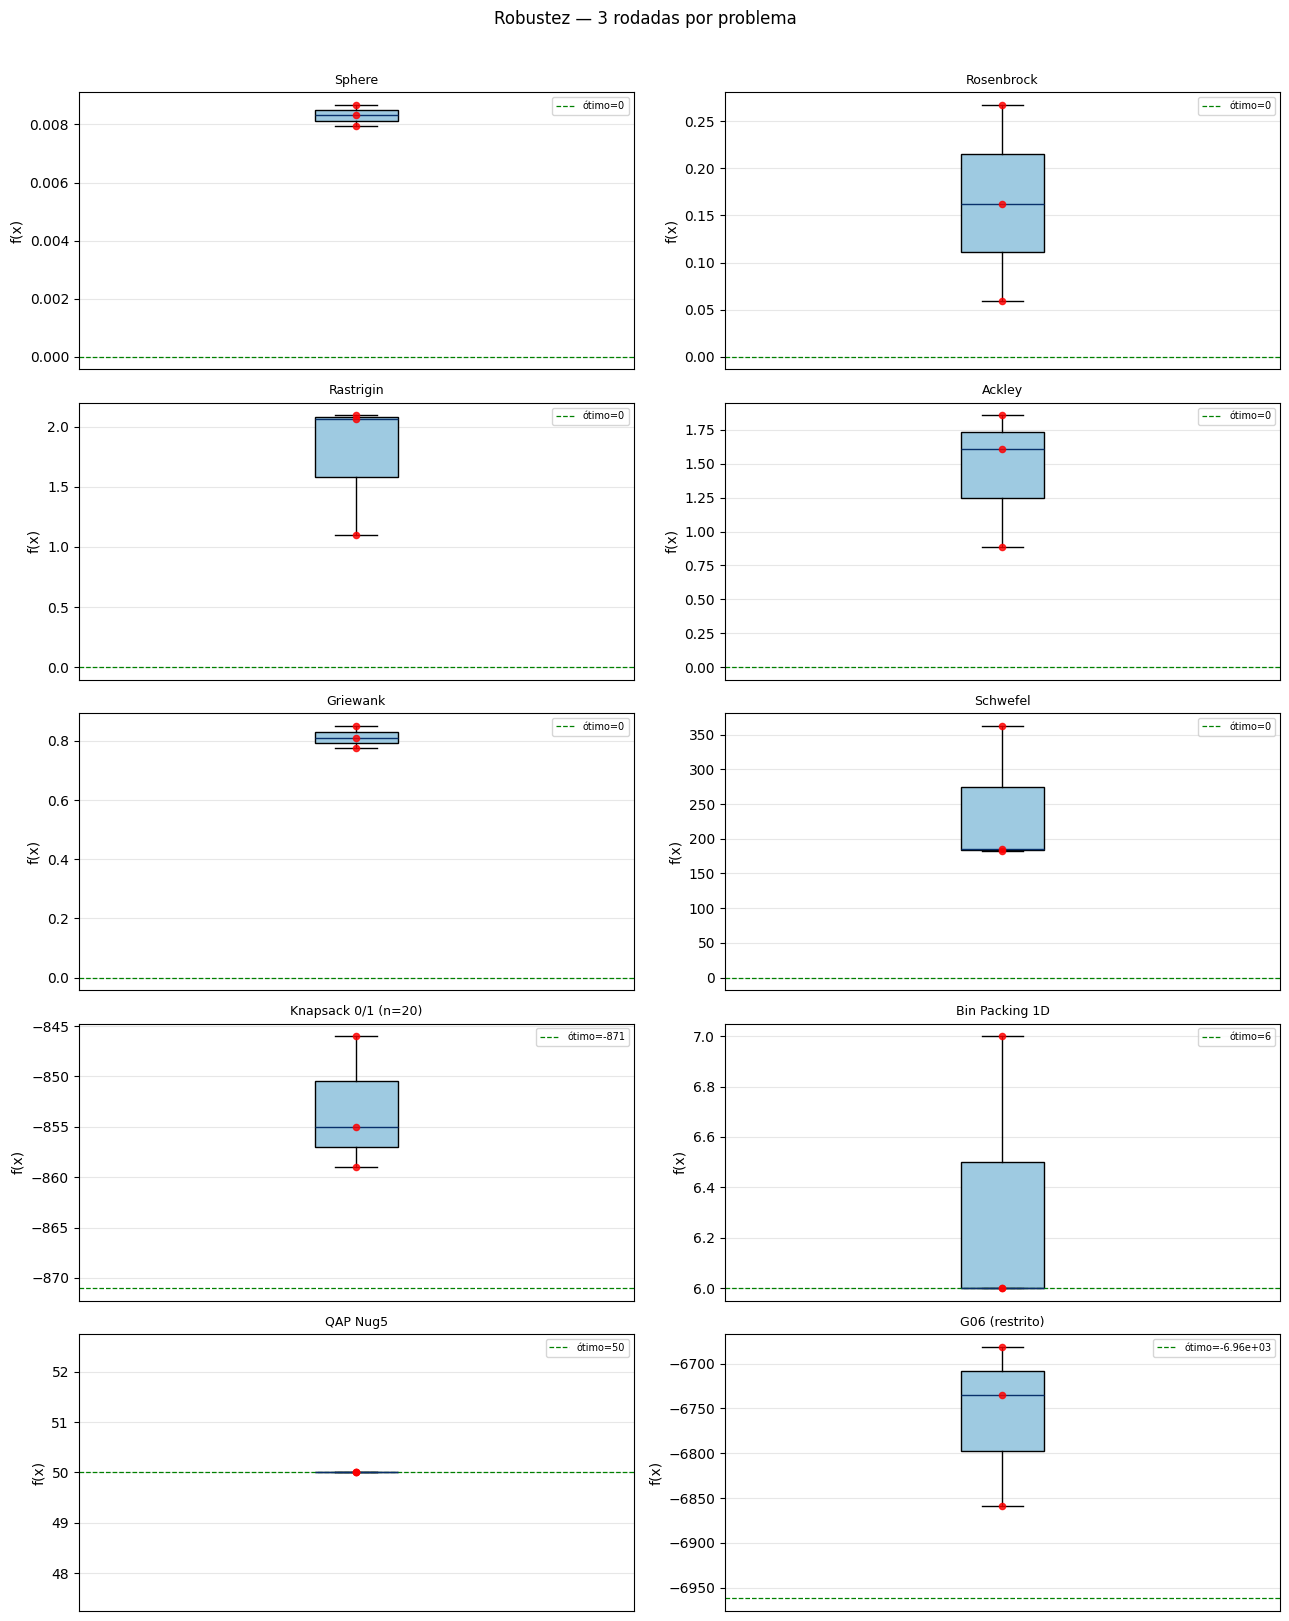

,Problema,Média,DP,CV (%)
0,QAP Nug5,50.0000,0.0000,0.0000
1,Knapsack 0/1 (n=20),-853.3333,5.4365,0.6371
2,G06 (restrito),-6758.4386,74.5030,1.1024
3,Sphere,0.0083,0.0003,3.5663
4,Griewank,0.8129,0.0302,3.7120
5,Bin Packing 1D,6.3333,0.4714,7.4432
6,Rastrigin,1.7513,0.4635,26.4654
7,Ackley,1.4512,0.4119,28.3815
8,Schwefel,243.4152,84.4496,34.6936
9,Rosenbrock,0.1630,0.0850,52.1586


In [ ]:
labels = [r["problem"] for r in ALL_RESULTS]
values_per_problem = [r["_solve_result"].values for r in ALL_RESULTS]
optima = [r["optimum"] for r in ALL_RESULTS]

fig, axes = plt.subplots(rows, cols, figsize=(13, 3.2 * rows))
axes_flat = np.atleast_1d(axes).flatten()
for ax, name, vals, opt in zip(
    axes_flat, labels, values_per_problem, optima, strict=False
):
    ax.boxplot(
        vals,
        vert=True,
        patch_artist=True,
        boxprops={"facecolor": "#9ecae1", "edgecolor": "black"},
        medianprops={"color": "#08306b"},
    )
    ax.axhline(
        opt, color="green", linestyle="--", linewidth=0.9, label=f"ótimo={opt:.3g}"
    )
    ax.scatter(np.ones_like(vals), vals, color="red", s=20, zorder=3, alpha=0.8)
    ax.set_title(name, fontsize=9)
    ax.set_xticks([])
    ax.set_ylabel("f(x)")
    ax.legend(fontsize=7, loc="upper right")

for ax in axes_flat[n_problems:]:
    ax.axis("off")

plt.suptitle(f"Robustez — {DEFAULT_RUNS} rodadas por problema", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Coeficiente de variação
df_cv = (
    pd.DataFrame(
        [
            {
                "Problema": r["problem"],
                "Média": r["mean_fun"],
                "DP": r["std_fun"],
                "CV (%)": (
                    100.0 * r["std_fun"] / abs(r["mean_fun"])
                    if r["mean_fun"] != 0
                    else np.nan
                ),
            }
            for r in ALL_RESULTS
        ]
    )
    .sort_values("CV (%)")
    .reset_index(drop=True)
)
display(df_cv.round(4))